# Artificial Intelligence Technology and Application

## Machine Learning Lab Guide - Student Version

Independent implementation prepared by **Sundetkhan Bekzat**.


# 1 Survival Prediction of the Titanic

This notebook keeps the lab objective but uses compact local examples so it can run without external datasets.


## 1.1 Synthetic Passenger Table
The structure mirrors passenger survival features without requiring the original CSV.


In [1]:
import numpy as np
import pandas as pd

rng = np.random.default_rng(15)
passengers = pd.DataFrame({
    "class": rng.choice([1, 2, 3], size=220, p=[0.22, 0.28, 0.50]),
    "sex": rng.choice(["female", "male"], size=220),
    "age": rng.normal(31, 12, size=220).clip(1, 75),
    "fare": rng.gamma(2.0, 18.0, size=220),
})
logits = 1.2 * (passengers["sex"] == "female") - 0.55 * passengers["class"] + passengers["fare"] / 120 - passengers["age"] / 90
passengers["survived"] = (rng.random(220) < 1 / (1 + np.exp(-logits))).astype(int)
print(passengers.head())


   class     sex        age       fare  survived
0      3    male  23.122779  48.218466         0
1      3  female  14.884717  31.043429         1
2      2    male  53.637567   4.487175         0
3      1    male  35.461752  42.133267         1
4      3  female  33.302791  26.415947         0


## 1.2 Model Comparison
Logistic regression and random forest are trained on the same encoded features.


In [2]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

X = pd.get_dummies(passengers.drop(columns="survived"), drop_first=True)
y = passengers["survived"]
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=15)
models = {
    "logistic": LogisticRegression(max_iter=500),
    "forest": RandomForestClassifier(n_estimators=80, random_state=15, max_depth=5),
}
for name, estimator in models.items():
    estimator.fit(X_train, y_train)
    print(name, round(accuracy_score(y_test, estimator.predict(X_test)), 3))


logistic 0.673
forest 0.636


## 1.3 Feature Importance
The forest ranking provides an interpretable summary.


In [3]:
forest = models["forest"]
ranking = sorted(zip(X.columns, forest.feature_importances_), key=lambda pair: pair[1], reverse=True)
print([(name, round(value, 3)) for name, value in ranking])


[('fare', np.float64(0.388)), ('age', np.float64(0.373)), ('sex_male', np.float64(0.178)), ('class', np.float64(0.061))]


## 1.4 Visualization
Average survival is grouped by passenger class.


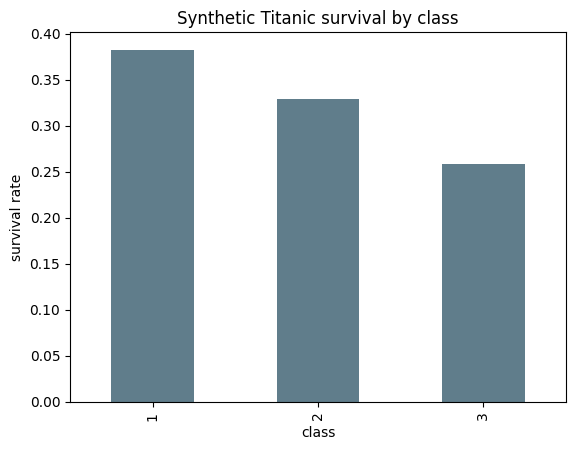

In [4]:
import matplotlib.pyplot as plt

passengers.groupby("class")["survived"].mean().plot(kind="bar", color="#607D8B")
plt.ylabel("survival rate")
plt.title("Synthetic Titanic survival by class")
plt.show()
